# CIBUSmod multi-processing example
This notebook privides an example of how to use multiple processes to run multiple scenarios/years faster.

### Import libraries
Add directory with the CIBUSmod modules to path to be able to import

In [1]:
import sys
import os
sys.path.insert(0, os.path.join(os.getcwd(),'..'))

Import CIBUSmod and packages for handling data and plotting

In [2]:
import CIBUSmod as cm
import CIBUSmod.utils.plot as plot

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Set up scenario and modules

Instantiate a `Session` object and define scenarios in the same way as in the single-processing case. To make multi-processing work we need to instantiate the CIBUSmod modules and define the calculations in a separate file. Here we use `multi_proc.py` for this. This file defines a function `do_run()`  which performes the calculations. It is important that the `name` and `data_path` parameters to create `Session` object in `multi_proc.py` matches the `name` and `data_path` defined below in this notebook.

In [3]:
# Create session
session = cm.Session(
    name = 'fai_multi_proc', # <--- Make sure that name and data_path match with multi_proc.py
    data_path = '../data'
)

# Define scenarios
session.add_scenario(
    name = 'FAI',
    scenario_workbooks = 'food_as_industry',
    modules = 'all',
    pars = 'all',
    years = list(range(2020,2050+1,5))
)
session.add_scenario(
    name = 'FAI_no_cows',
    scenario_workbooks = ['food_as_industry', 'no_cows'], 
    modules = 'all',
    pars = 'all',
    years = list(range(2020,2050+1,5))
)

A scenario with the name 'FAI' already exists use .update_scenario() or .remove_scenario() instead.
A scenario with the name 'FAI_no_cows' already exists use .update_scenario() or .remove_scenario() instead.


### Run calculations
The code below initiates a process pool that executes the model runs. The `max_workers` paramter to `ProcessPoolExecutor()` defines the maximum number of concurrent processes. The ideal value for this will depend on the computer. The code will print a message every time a scenario run has finnished and if a scenario run fails it will print an error message.

In [4]:
# Import
from concurrent.futures import ProcessPoolExecutor, as_completed
from multi_proc import do_run

# Create list of scenarios/years to run
runs = [(s,y) for s, y in session.iterate('all')]

In [5]:
%%time
# Do the multi-processing
with ProcessPoolExecutor(max_workers=8) as executor:
    
    futures = {executor.submit(do_run, scn_year) : scn_year for scn_year in runs}

    for future in as_completed(futures):
    
        scn, year = futures[future]
           
        try:
            t = future.result()
        except Exception as ee:
            print(f'(!!!) {scn}, {year} failed with the exception: {ee}')
        else:
            m = int(t/60)
            s = int(round(t - m*60))
            print(f'{scn}, {year} finished successfully in {m}min {s}s')
                    

FAI, 2040 finished successfully in 5min 9s
FAI, 2020 finished successfully in 5min 36s
FAI, 2030 finished successfully in 6min 3s
FAI, 2050 finished successfully in 6min 5s
FAI, 2035 finished successfully in 6min 6s
FAI_no_cows, 2020 finished successfully in 6min 10s
FAI, 2045 finished successfully in 6min 19s
FAI, 2025 finished successfully in 6min 22s
FAI_no_cows, 2025 finished successfully in 2min 54s
FAI_no_cows, 2030 finished successfully in 3min 54s
FAI_no_cows, 2035 finished successfully in 3min 60s
FAI_no_cows, 2050 finished successfully in 4min 14s
FAI_no_cows, 2045 finished successfully in 4min 21s
FAI_no_cows, 2040 finished successfully in 4min 23s
CPU times: total: 15.6 ms
Wall time: 10min 45s


## Plot output
Here are some example output plots.

In [ ]:
session

FAI
---


<timed exec>:19: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.


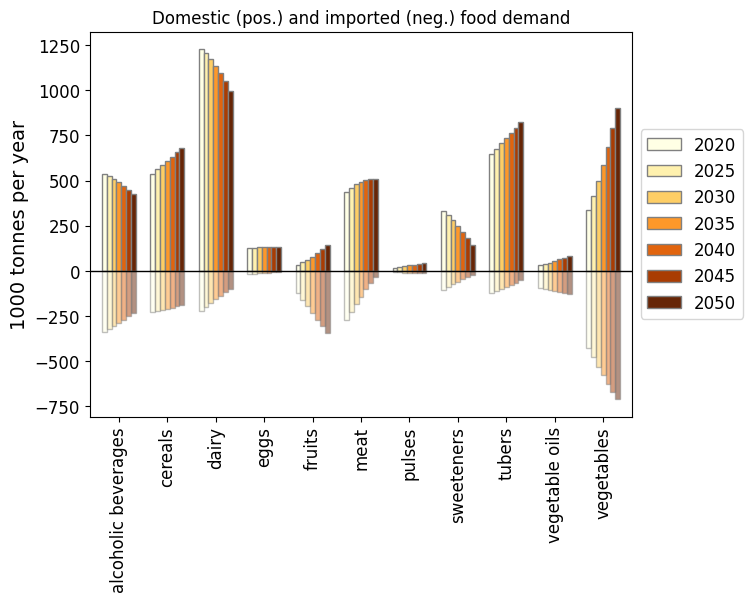

FAI_no_cows
-----------


<timed exec>:19: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.


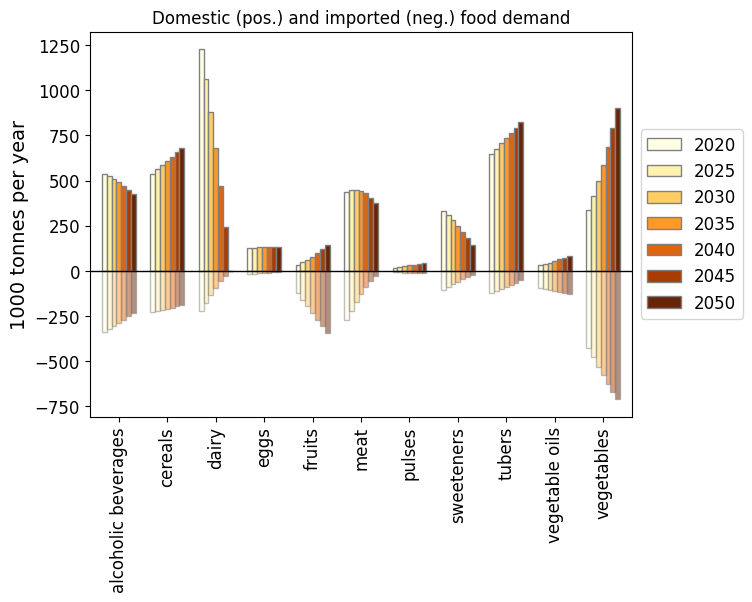

CPU times: total: 625 ms
Wall time: 804 ms


In [7]:
%%time
style = {
    'kind' : 'bar',
    'cmap' : 'YlOrBr',
    'edgecolor' : 'grey',
    'legend' : False,
    'width' : 0.7
}

for scn in session.scenarios():
    print(scn)
    print('-'*len(scn))
    
    plot_data = (
        session.get_attr(
            module='D',
            attr='food_demand_to_processing',
            groupby=['origin','food_group']
        ).loc[scn]
        .stack()
    )/1000000
    plot_data.loc[:,'imported'] = -plot_data.loc[:,'imported']
    
    fig, ax = plt.subplots(figsize=(7,5))
    plot_data['domestic'].unstack('year').plot(**style, ax=ax)
    (
        plot_data['imported'].unstack('year')
        .rename({x:'_' for x in plot_data.index.get_level_values('year').unique()}, axis=1)
    ).plot(**style, ax=ax, alpha=0.5)
    
    plt.hlines(0,-1,11, color='black', linewidth=1)
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.set_ylabel('1000 tonnes per year', size=14)
    ax.set_title('Domestic (pos.) and imported (neg.) food demand', size=12)
    ax.set_xlabel('')
    ax.legend(loc='center left', ncol=1, bbox_to_anchor=(1, 0.5), fontsize=12)
    
    # plt.tight_layout()
    plt.show()

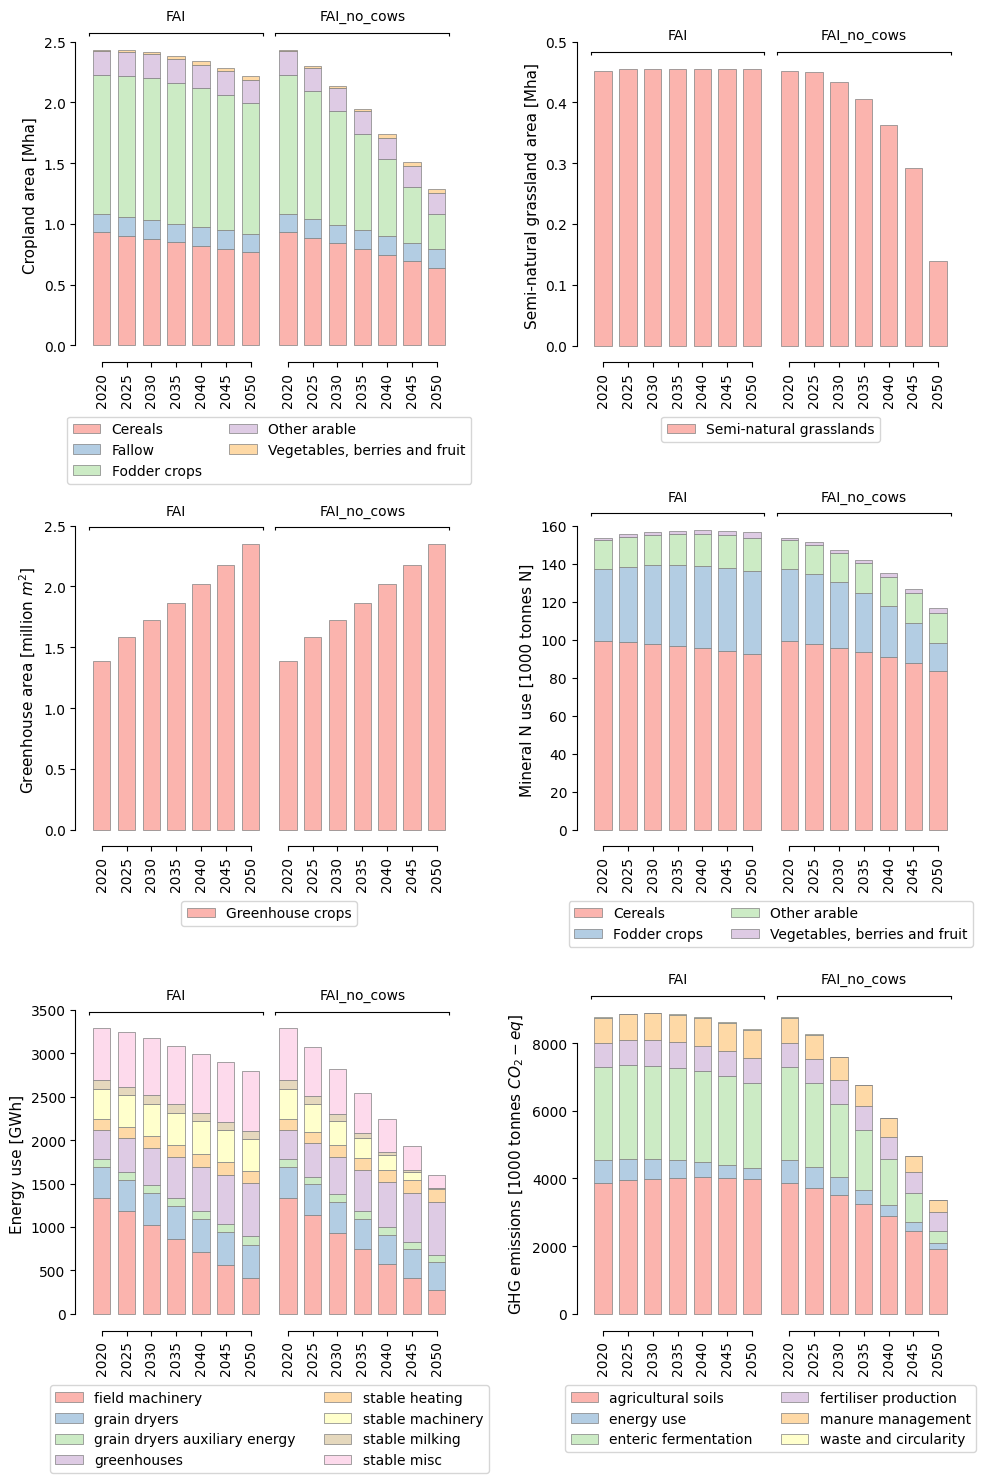

In [8]:
style = {
    'stacked' : True,
    'cmap' : 'Pastel1',
    'edgecolor' : 'grey',
    'bar_width' : 0.7
}

fig, axs = plt.subplots(3,2, figsize=(10,15))

# Land use --->
plot_data = session.get_attr('C','area',{'crop':'crop_group2'})/1000000

# Cropland
ax = axs[0,0]
plot.bar(
    plot_data.drop(['Semi-natural grasslands','Greenhouse crops'], axis=1),
    **style,
    ax=ax,
    group_levels='scn',
    ylabel='Cropland area [Mha]'
)

# Semi-natural grassland
ax = axs[0,1]
plot.bar(
    plot_data.xs('Semi-natural grasslands', axis=1),
    **style,
    ax=ax,
    group_levels='scn',
    ylabel='Semi-natural grassland area [Mha]'
)

# Greenhouse
ax = axs[1,0]
plot.bar(
    plot_data.xs('Greenhouse crops', axis=1),
    **style,
    ax=ax,
    group_levels='scn',
    ylabel=r'Greenhouse area [million $m^2$]'
)

# Mineral N use --->
ax = axs[1,1]
plot.bar(
    (session.get_attr('C','fertiliser.mineral_N',{'crop':'crop_group2'})/1000000),
    **style,
    ax=ax,
    group_levels='scn',
    ylabel='Mineral N use [1000 tonnes N]'
)

# Energy use --->
ax = axs[2,0]
plot.bar(
    pd.concat([
        session.get_attr('C','energy_use','activity'),
        session.get_attr('A','energy_use','activity')
    ], axis=1)/1000000,
    **style,
    ax=ax,
    group_levels='scn',
    ylabel='Energy use [GWh]'
)

# GHG emissions
ax = axs[2,1]
plot_data = (
    cm.get_GHG(session)
    .T.groupby('process').sum().T
)/1000000
plot.bar(
    plot_data,
    **style,
    ax=ax,
    group_levels='scn',
    ylabel=r'GHG emissions [1000 tonnes $CO_{2}-eq$]'
)

for ax in axs.flatten():
    ax.legend(loc='upper center', ncol=2, bbox_to_anchor=(0.5, -0.2), fontsize=10)

plt.tight_layout()
plt.show()

In [9]:
plot_data.loc['FAI']

process,agricultural soils,energy use,enteric fermentation,fertiliser production,manure management,waste and circularity
year,,,,,,
2020,3854.918976,680.526139,2743.061136,727.907293,736.932458,14.060107
2025,3939.653145,626.375120,2772.787045,739.035659,770.017199,14.546695
2030,3994.559112,568.821951,2772.311442,747.420960,795.144029,14.975772
2035,4021.885016,509.940429,2740.510769,753.037368,811.820919,15.344008
2040,4029.542240,451.516722,2685.240571,757.018830,821.905025,15.692927
2045,4016.508480,393.732955,2606.822869,759.076638,824.964221,16.015932
2050,3975.022580,336.267346,2500.331295,757.865252,818.800285,16.270880


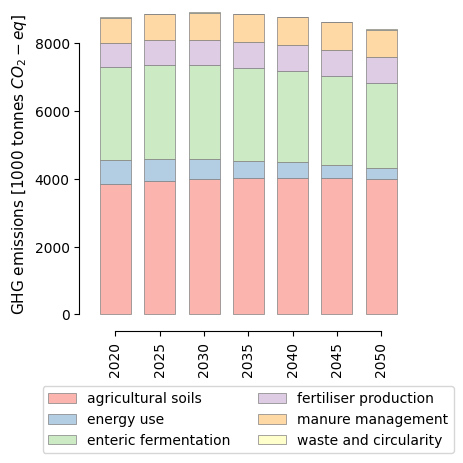

In [10]:
fig,ax = plt.subplots(figsize=(4,4))
plot_data = (
    cm.get_GHG(session)
    .T.groupby('process').sum().T
)/1000000
plot.bar(
    plot_data.loc['FAI'],
    **style,
    ax=ax,
    ylabel=r'GHG emissions [1000 tonnes $CO_{2}-eq$]'
)
ax.legend(loc='upper center', ncol=2, bbox_to_anchor=(0.5, -0.2), fontsize=10)

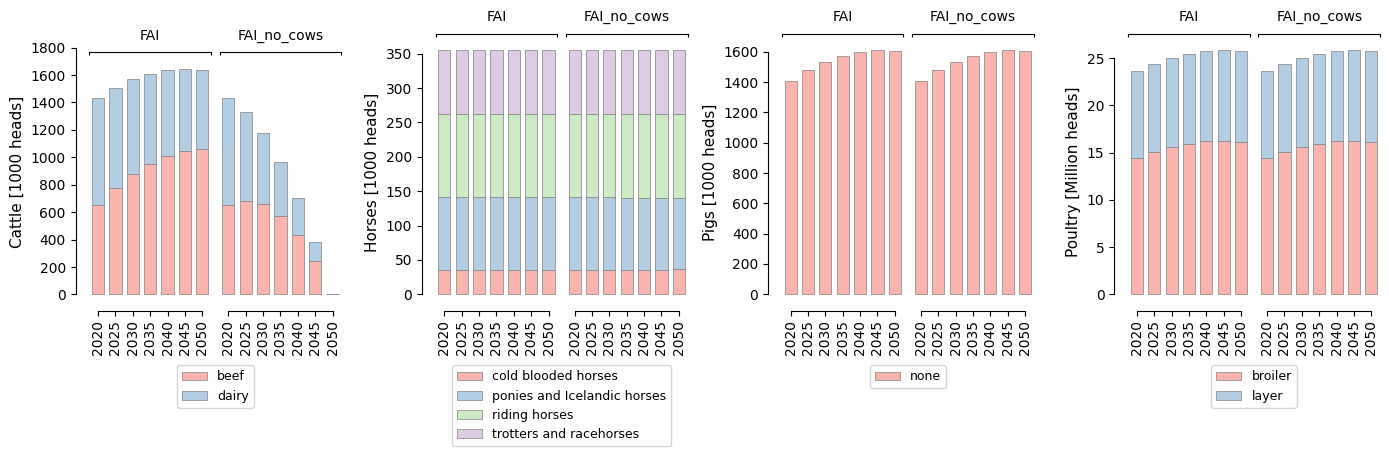

CPU times: total: 2.08 s
Wall time: 2.64 s


In [11]:
%%time
style = {
    'stacked' : True,
    'cmap' : 'Pastel1',
    'edgecolor' : 'grey',
    'bar_width' : 0.7
}
    
# Number of animal heads
plot_data = session.get_attr('A','heads',['species','breed'])

fig, axs = plt.subplots(1,4, figsize=(14,5))

for ax,sp in zip(axs,plot_data.columns.get_level_values('species').unique()):

    plot.bar(
        (plot_data / (1000000 if sp=='poultry' else 1000))
        .xs(sp, level='species', axis=1),
        **style,
        ax=ax,
        group_levels='scn',
        ylabel=sp.capitalize() + (' [Million heads]' if sp=='poultry' else ' [1000 heads]')
    )

    # ax.legend(loc='lower left', bbox_to_anchor=(0, 0))

for ax in axs.flatten():
    ax.legend(loc='upper center', ncol=1, bbox_to_anchor=(0.5, -0.25), fontsize=9)

plt.tight_layout()
plt.show()

FAI
---


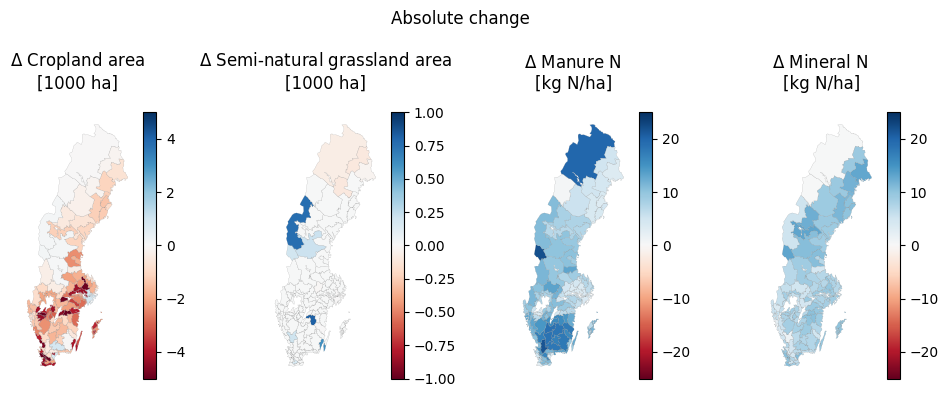

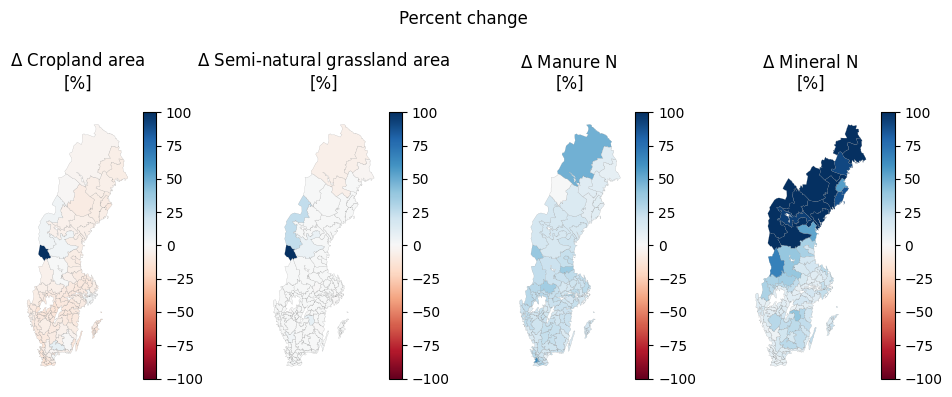

FAI_no_cows
-----------


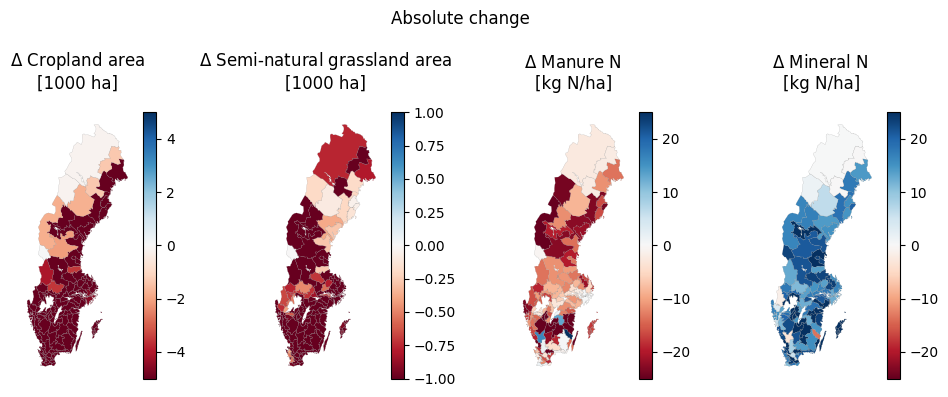

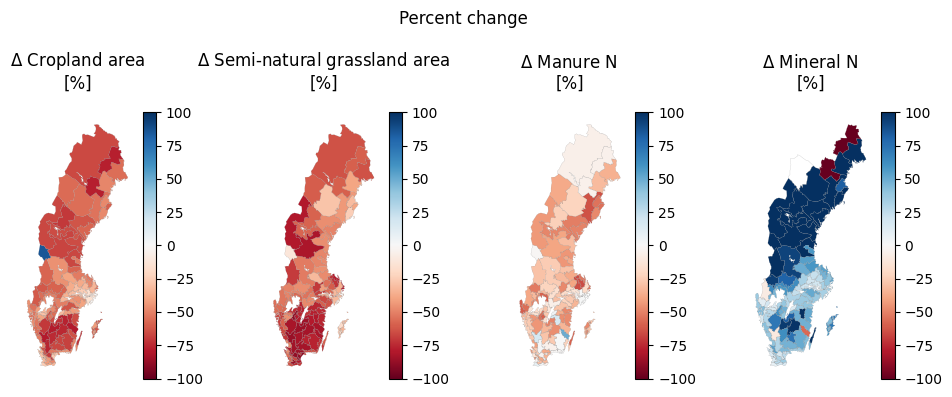

CPU times: total: 14.4 s
Wall time: 17.8 s


In [12]:
%%time
for scn in session.scenarios():
    print(scn)
    print('-'*len(scn))
    
    y0 = session.scenarios()[scn][0]
    yend = session.scenarios()[scn][-1]

    # ABSOLUTE
    fig, axs = plt.subplots(1,4, figsize=(10,4))
    
    # LAND USE -------->
    plot_data = session.get_attr('C','area',{'crop':'land_use','region':None}).loc[scn]/1000
    plot_data = plot_data.loc[yend] - plot_data.loc[y0]
    # Cropland area --->
    ax = axs[0]
    plot.map_from_series(
        plot_data.loc['cropland'],
        cmap='RdBu',
        vmin=-5,
        vmax=5,
        edgecolor='grey',
        ax=ax
    )
    ax.set_title('$\Delta$ Cropland area\n[1000 ha]')
    ax.set_axis_off()

    # Grassland area --->
    ax = axs[1]
    plot.map_from_series(
        plot_data.loc['semi-natural grasslands'],
        cmap='RdBu',
        vmin=-1,
        vmax=1,
        edgecolor='grey',
        ax=ax
    )
    ax.set_title('$\Delta$ Semi-natural grassland area\n[1000 ha]')
    ax.set_axis_off()

    # Manure N application --->
    plot_data = session.get_attr('C','fertiliser.manure_N',{'crop':'land_use','region':None}).loc[scn,'cropland'] \
    / session.get_attr('C','area',{'crop':'land_use','region':None}).loc[scn,'cropland']
    plot_data = plot_data.loc[yend] - plot_data.loc[y0]
    
    ax = axs[2]
    plot.map_from_series(
        plot_data,
        cmap='RdBu',
        vmin=-25,
        vmax=25,
        edgecolor='grey',
        ax=ax
    )
    ax.set_title('$\Delta$ Manure N \n[kg N/ha]')
    ax.set_axis_off()

    # Mineral N application --->
    plot_data = session.get_attr('C','fertiliser.mineral_N',{'crop':'land_use','region':None}).loc[scn,'cropland'] \
    / session.get_attr('C','area',{'crop':'land_use','region':None}).loc[scn,'cropland']
    plot_data = plot_data.loc[yend] - plot_data.loc[y0]
    
    ax = axs[3]
    plot.map_from_series(
        plot_data,
        cmap='RdBu',
        vmin=-25,
        vmax=25,
        edgecolor='grey',
        ax=ax
    )
    ax.set_title('$\Delta$ Mineral N \n[kg N/ha]')
    ax.set_axis_off()

    
    plt.suptitle('Absolute change')
    plt.tight_layout()
    plt.show()

    # PERCENT
    fig, axs = plt.subplots(1,4, figsize=(10,4))
    
    # LAND USE -------->
    plot_data = session.get_attr('C','area',{'crop':'land_use','region':None}).loc[scn]/1000
    plot_data = (plot_data.loc[yend] - plot_data.loc[y0]) / plot_data.loc[y0] * 100
    # Cropland area --->
    ax = axs[0]
    plot.map_from_series(
        plot_data.loc['cropland'],
        cmap='RdBu',
        vmin=-100,
        vmax=100,
        edgecolor='grey',
        ax=ax
    )
    ax.set_title('$\Delta$ Cropland area\n[%]')
    ax.set_axis_off()

    # Grassland area --->
    ax = axs[1]
    plot.map_from_series(
        plot_data.loc['semi-natural grasslands'],
        cmap='RdBu',
        vmin=-100,
        vmax=100,
        edgecolor='grey',
        ax=ax
    )
    ax.set_title('$\Delta$ Semi-natural grassland area\n[%]')
    ax.set_axis_off()

    # Manure N application --->
    plot_data = session.get_attr('C','fertiliser.manure_N',{'crop':'land_use','region':None}).loc[scn,'cropland'] \
    / session.get_attr('C','area',{'crop':'land_use','region':None}).loc[scn,'cropland']
    plot_data = (plot_data.loc[yend] - plot_data.loc[y0]) / plot_data.loc[y0] * 100
    
    ax = axs[2]
    plot.map_from_series(
        plot_data,
        cmap='RdBu',
        vmin=-100,
        vmax=100,
        edgecolor='grey',
        ax=ax
    )
    ax.set_title('$\Delta$ Manure N \n[%]')
    ax.set_axis_off()

    # Mineral N application --->
    plot_data = session.get_attr('C','fertiliser.mineral_N',{'crop':'land_use','region':None}).loc[scn,'cropland'] \
    / session.get_attr('C','area',{'crop':'land_use','region':None}).loc[scn,'cropland']
    plot_data = (plot_data.loc[yend] - plot_data.loc[y0]) / plot_data.loc[y0] * 100
    
    ax = axs[3]
    plot.map_from_series(
        plot_data,
        cmap='RdBu',
        vmin=-100,
        vmax=100,
        edgecolor='grey',
        ax=ax
    )
    ax.set_title('$\Delta$ Mineral N \n[%]')
    ax.set_axis_off()
   
    
    plt.suptitle('Percent change')
    plt.tight_layout()
    plt.show()

FAI
---


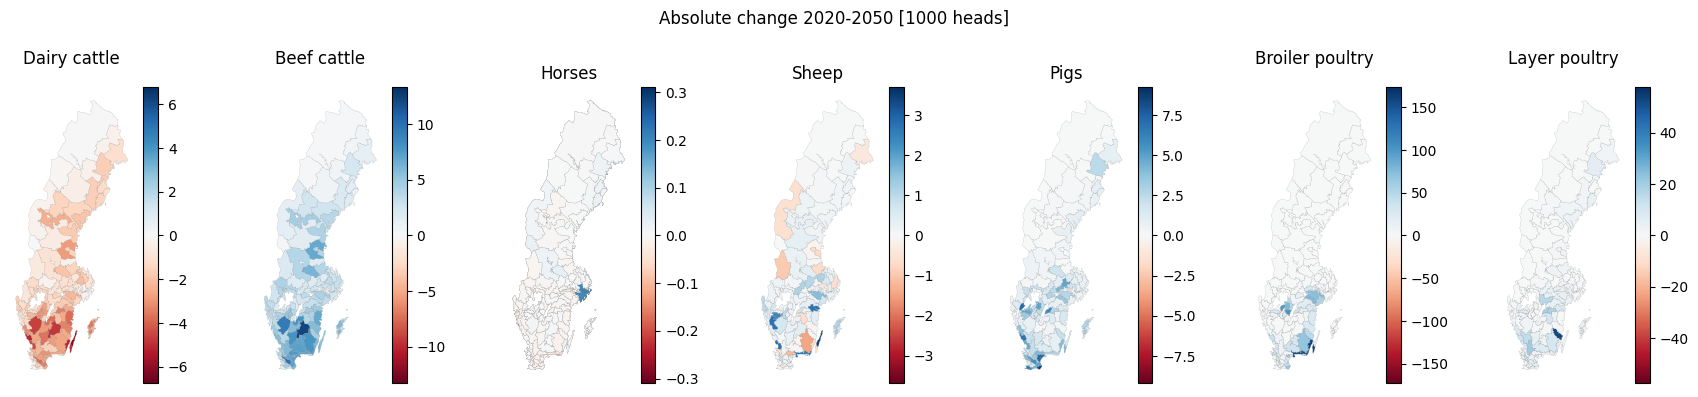

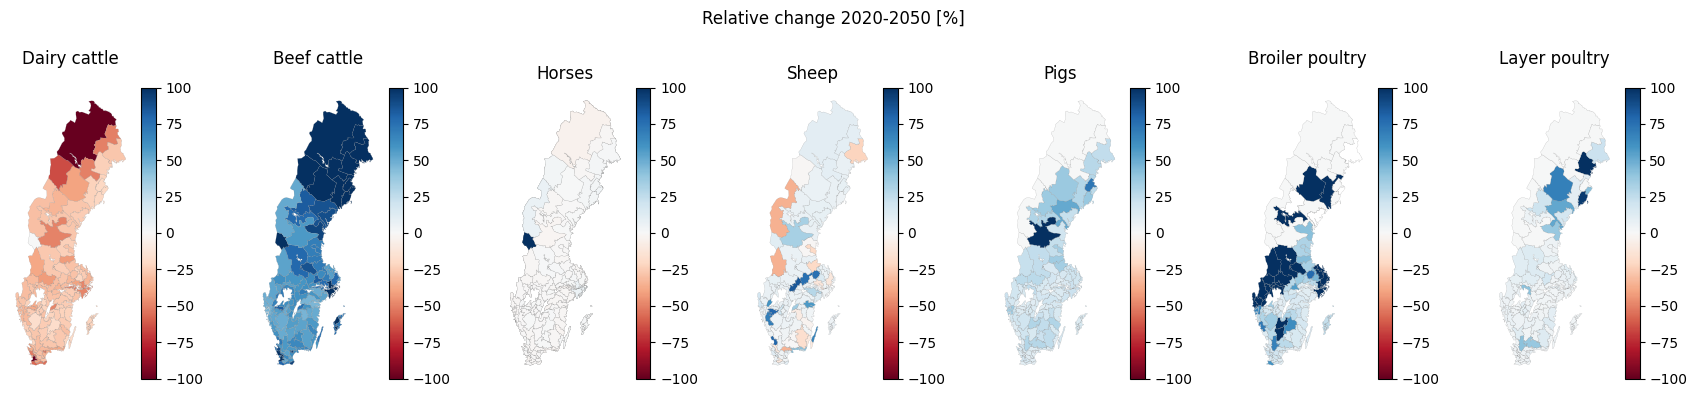

FAI_no_cows
-----------


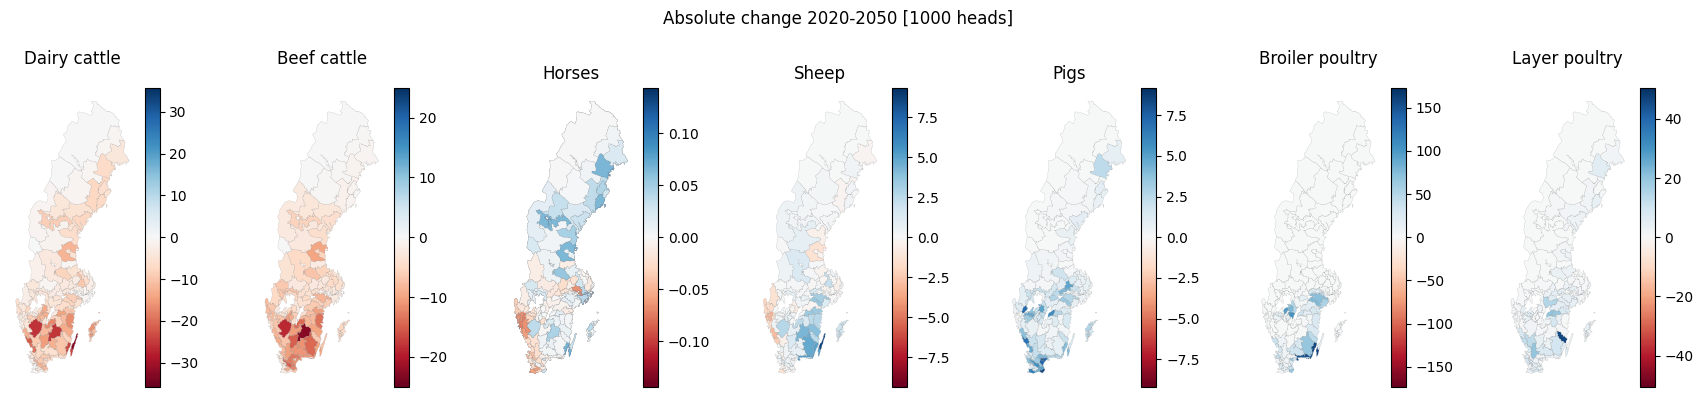

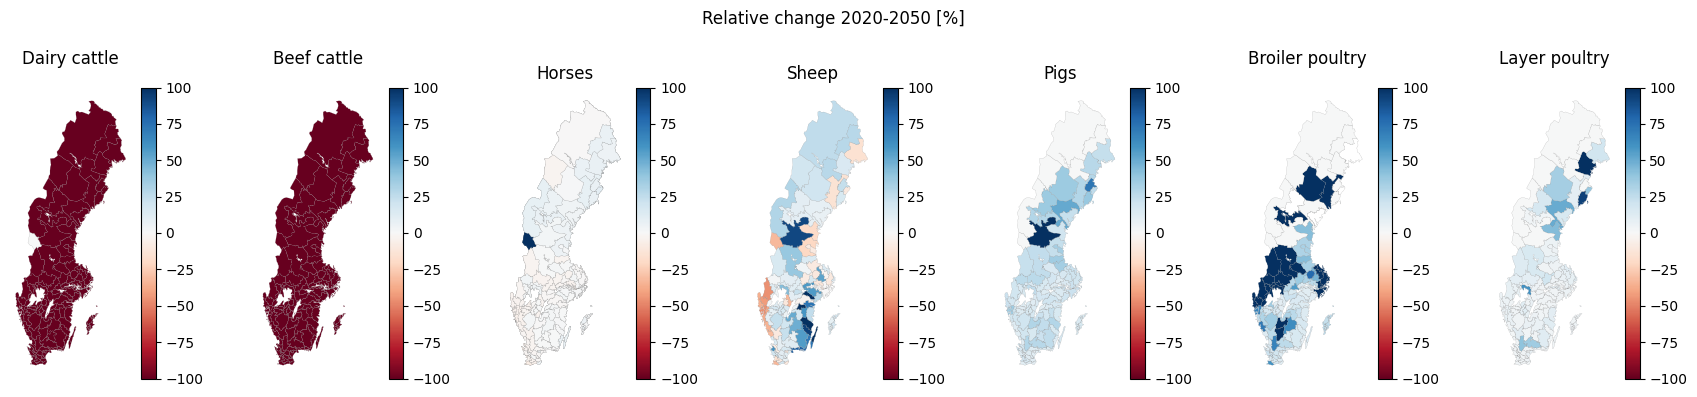

CPU times: total: 12.5 s
Wall time: 15.1 s


In [13]:
%%time
selection = {
    'Dairy cattle':('cattle','dairy'),
    'Beef cattle':('cattle','beef'),
    'Horses':('horses',slice(None)),
    'Sheep':('sheep',slice(None)),
    'Pigs':('pigs',slice(None)),
    'Broiler poultry':('poultry','broiler'),
    'Layer poultry':('poultry','layer')
}

for scn in session.scenarios():
    print(scn)
    print('-'*len(scn))
    
    plot_data = session.get_attr('A','heads',['species','breed','region']).loc[scn]/1000
    plot_data_abs = (plot_data.loc['2050'] - plot_data.loc['2020']).sort_index()
    plot_data_prc = ((plot_data.loc['2050'] - plot_data.loc['2020']) / plot_data.loc['2020'] * 100).sort_index().fillna(0)
    
    # ABSOLUTE
    fig, axs = plt.subplots(1,len(selection), figsize=(len(selection)*2.5,4))
    for ax,sel in zip(axs,selection):
        d = plot_data_abs.loc[selection[sel]]
        lim = max(abs(d))
        plot.map_from_series(
            d,
            ax=ax,
            cmap='RdBu',
            vmin=-lim*1.1,
            vmax=lim*1.1,
            edgecolor='grey'
        )
        ax.axis('off')
        ax.set_title(sel)  
    plt.suptitle('Absolute change 2020-2050 [1000 heads]')
    plt.tight_layout()
    plt.show()
    
    # PERCENT
    fig, axs = plt.subplots(1,len(selection), figsize=(len(selection)*2.5,4))
    for ax,sel in zip(axs,selection):
        d = plot_data_prc.loc[selection[sel]]
        lim = max(abs(d))
        plot.map_from_series(
            d,
            ax=ax,
            cmap='RdBu',
            vmin=-100,
            vmax=100,
            edgecolor='grey'
        )
        ax.axis('off')
        ax.set_title(sel)
    plt.suptitle('Relative change 2020-2050 [%]')
    plt.tight_layout()
    plt.show()

### Detailed changes across regions
Here are some plots that show how changes in the scenarios are distributed across regions by the optimisation algorithm implemented in the `GeoDistributor`.

FAI
---


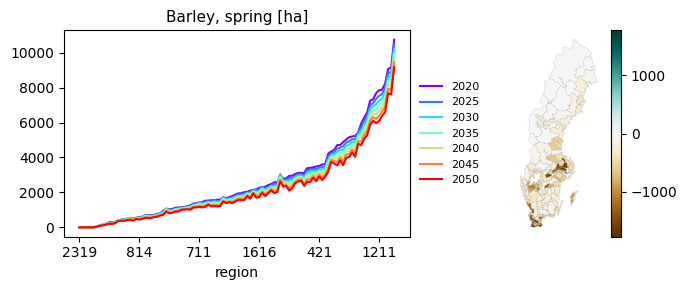

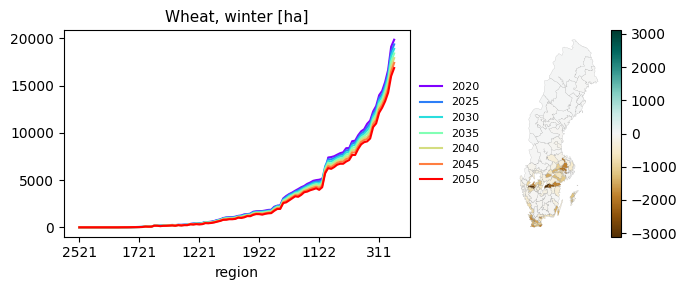

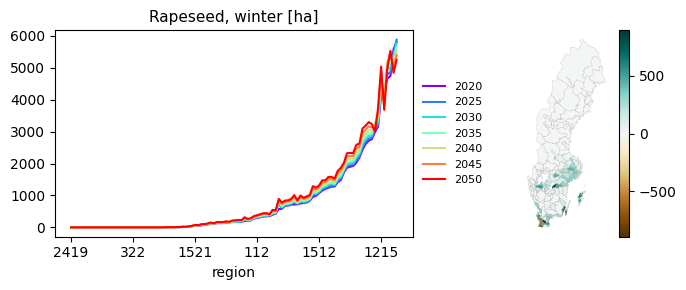

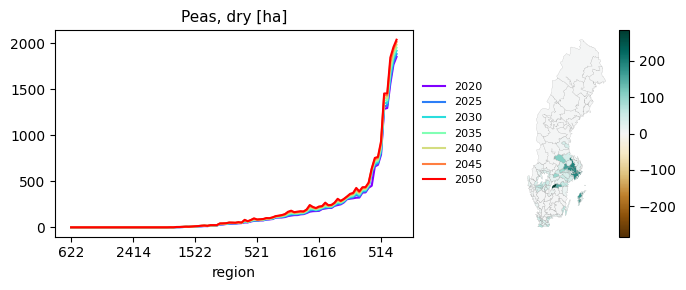

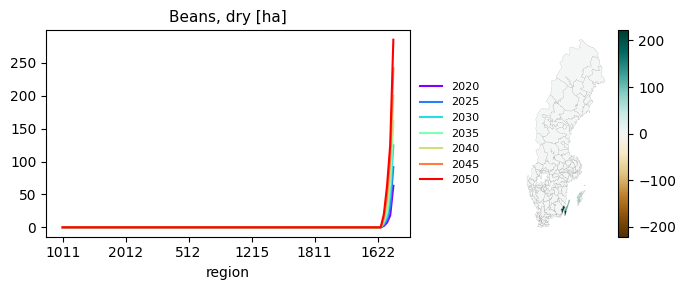

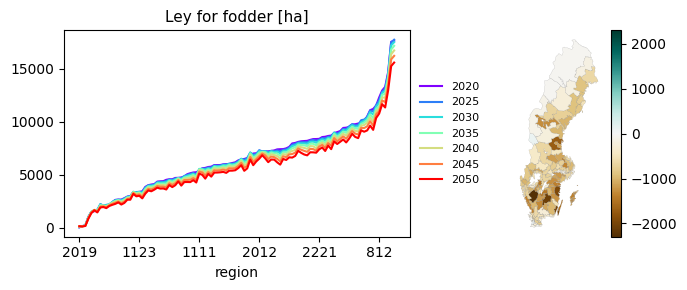

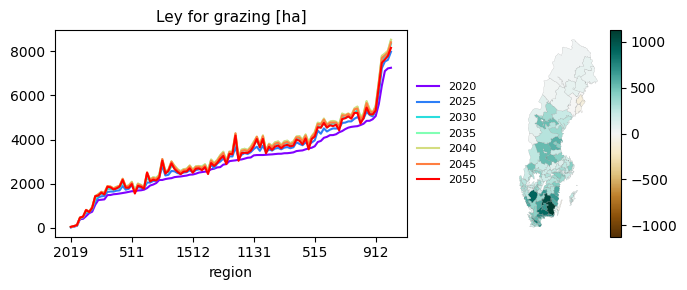

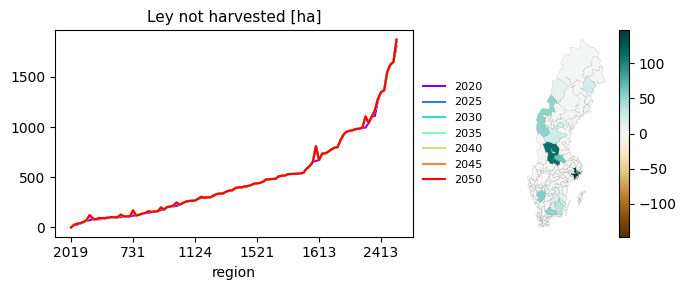

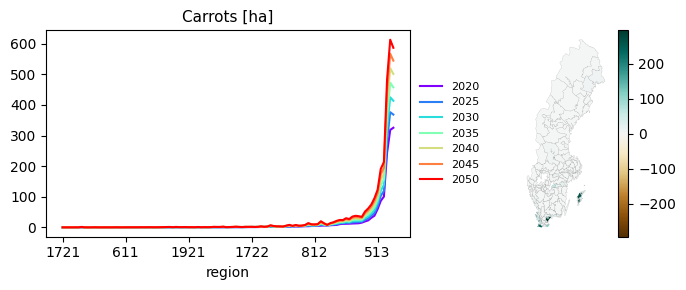

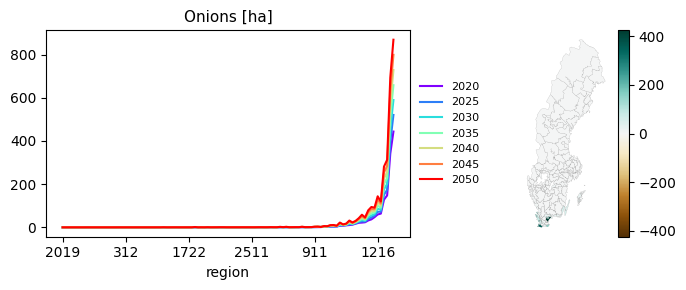

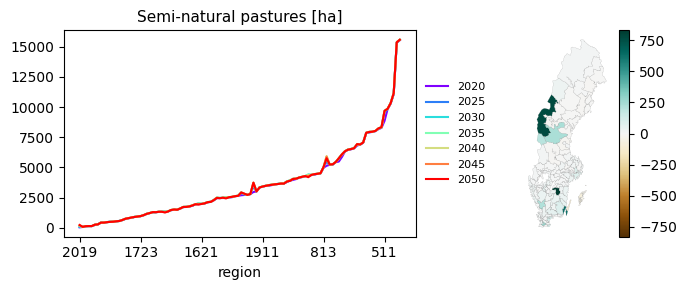

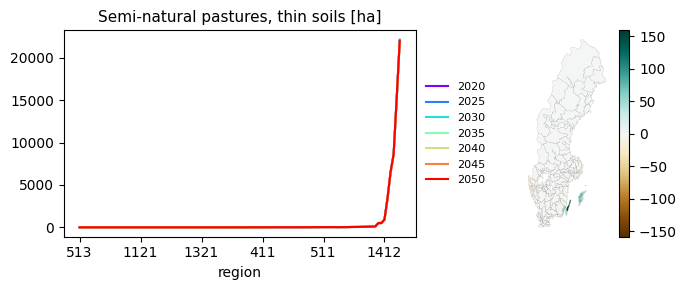

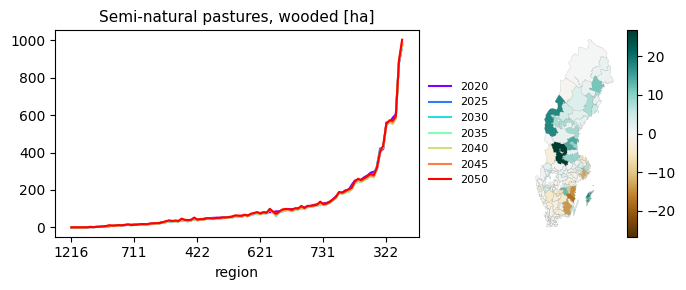

FAI_no_cows
-----------


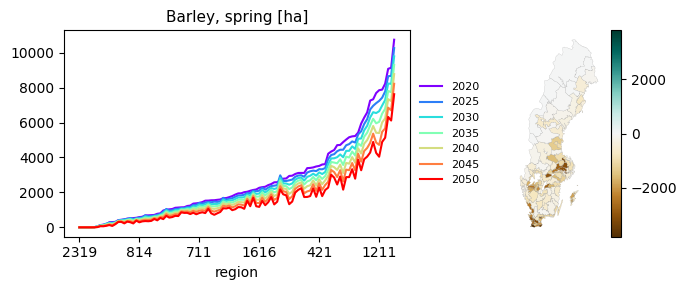

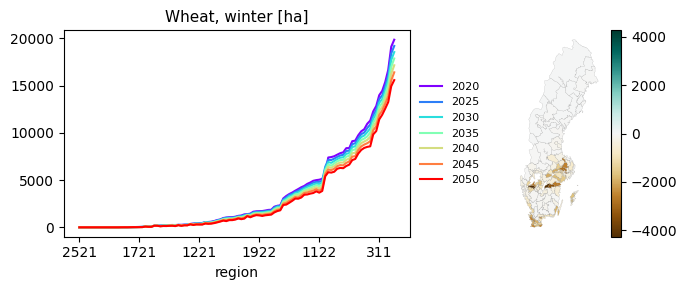

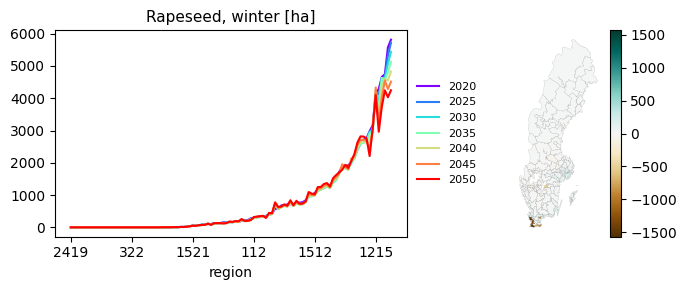

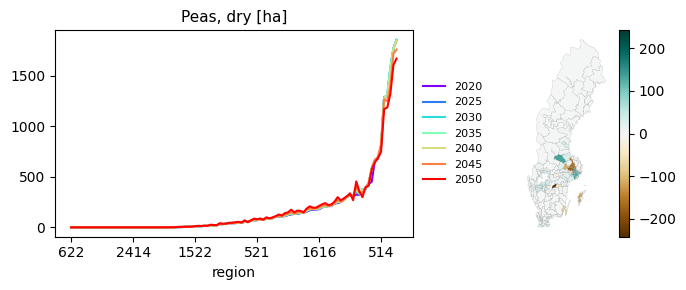

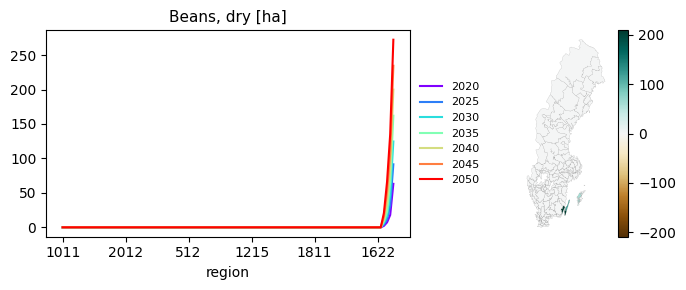

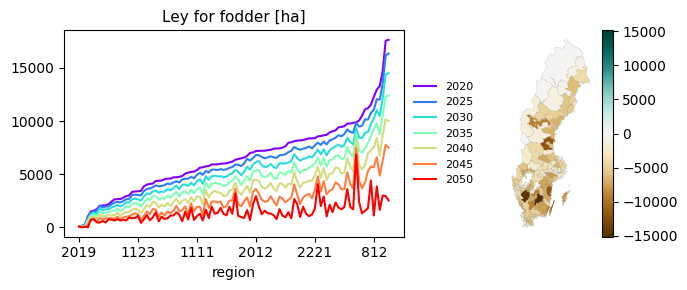

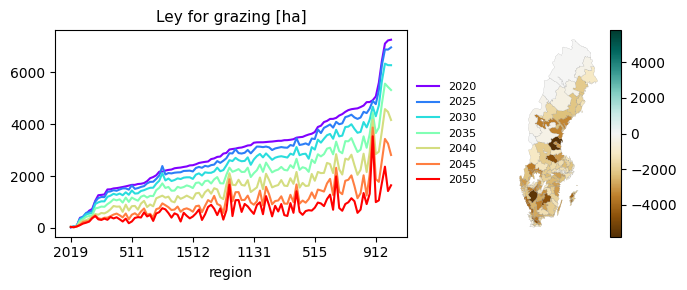

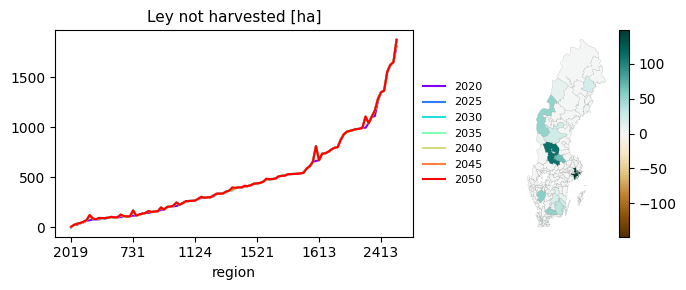

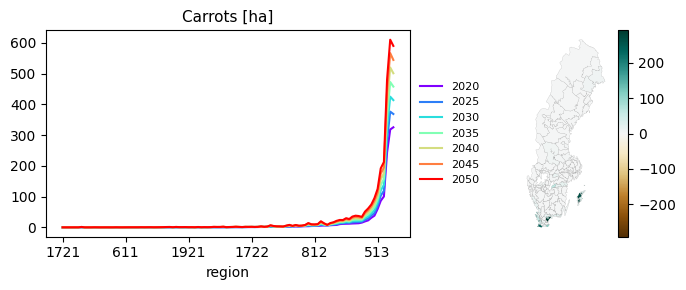

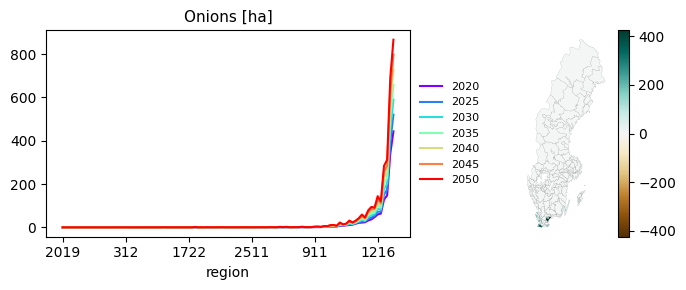

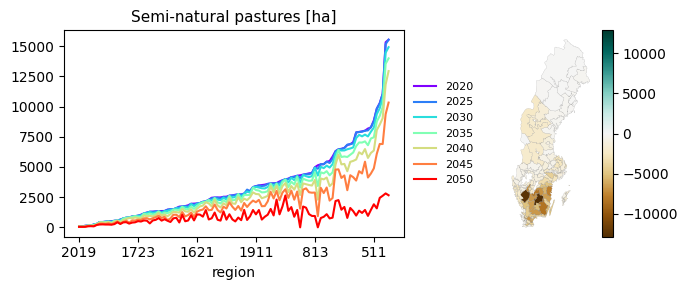

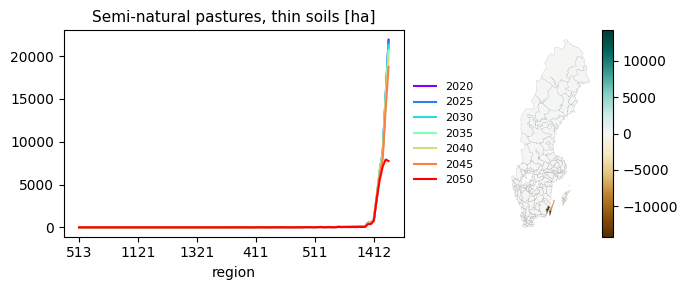

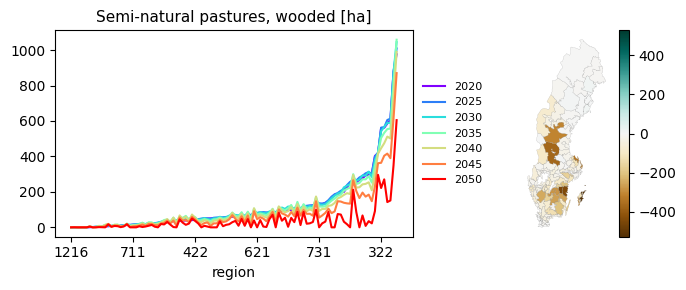

In [14]:
for scn in session.scenarios():
    print(scn)
    print('-'*len(scn))
    
    years = session.scenarios()[scn]
    plot_data_ = session.get_attr('C','area',['crop','region'], scn=scn).droplevel('scn').T

    crps = ['Barley, spring','Wheat, winter',
            'Rapeseed, winter',
            'Peas, dry', 'Beans, dry',
            'Ley for fodder','Ley for grazing', 'Ley not harvested',
            'Carrots','Onions',
            'Semi-natural pastures','Semi-natural pastures, thin soils','Semi-natural pastures, wooded']
    for crp in crps:
        plot_data = plot_data_.loc[crp].groupby('region').sum()
        plot_data['dif'] = (plot_data[years[-1]]-plot_data[years[0]])
        plot_data.sort_values(by=years[0], inplace=True)
    
        fig, axs = plt.subplots(1,2, figsize=(7,3), gridspec_kw={'width_ratios': [2, 1]})
        ax=axs[0]
        plot_data.plot(ax=ax, y=years, kind='line', marker='', linestyle='-', cmap='rainbow')
        # ax.set_yscale('log')
        ax.set_title(crp+' [ha]', size=11)
        ax.legend(loc='center left', ncols=1, bbox_to_anchor=(1, 0.5), frameon=False, fontsize=8)
    
        ax=axs[1]
        lim = max(abs(plot_data['dif']))
        plot.map_from_series(
            plot_data['dif'].replace({np.inf:0, -np.inf:0}).fillna(0),
            ax=ax, vmin=-lim, vmax=lim, cmap='BrBG', edgecolor='grey'
        )
        ax.axis('off')
    
        plt.tight_layout()
        plt.show()

FAI
---


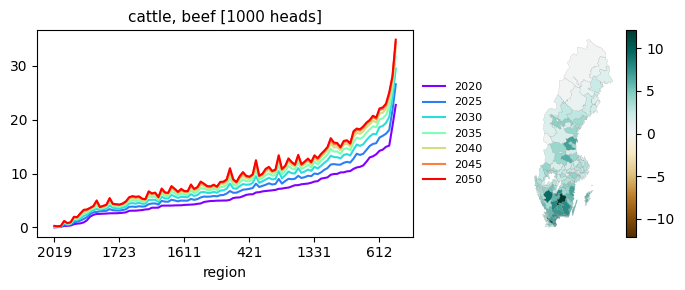

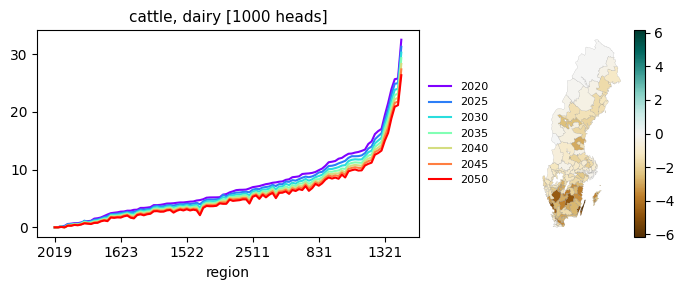

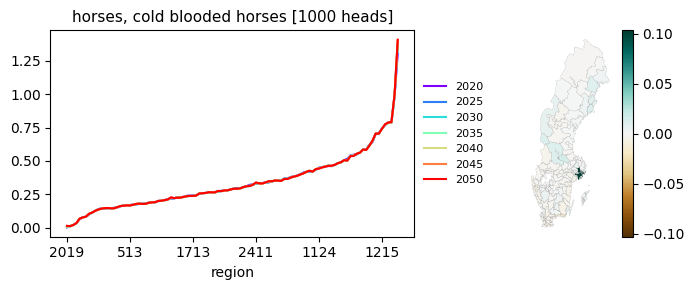

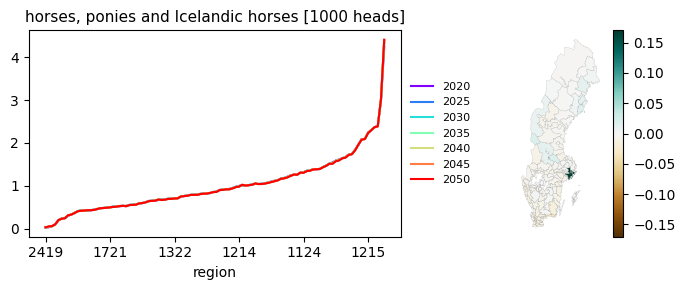

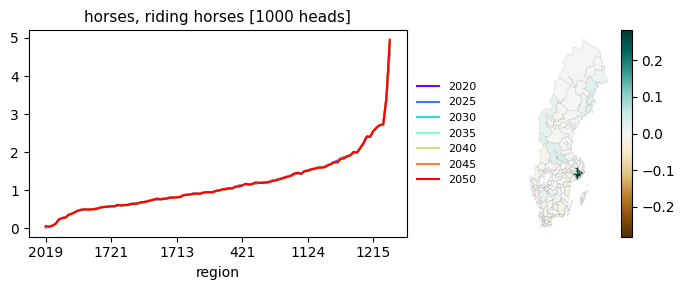

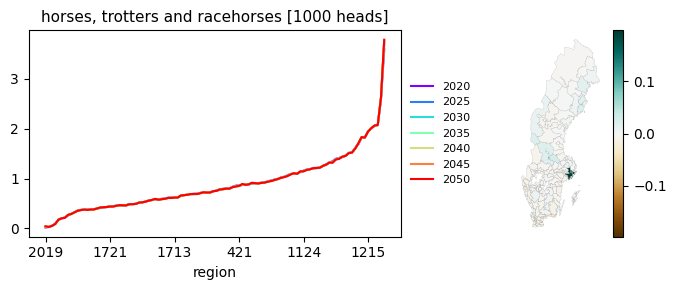

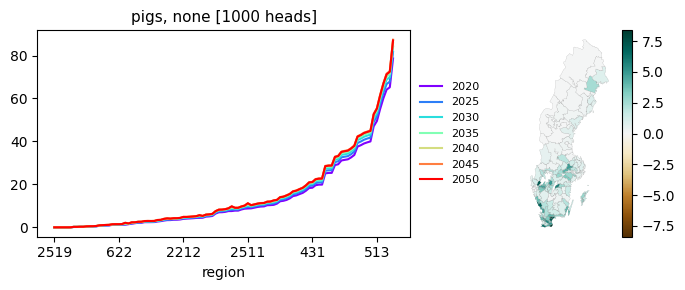

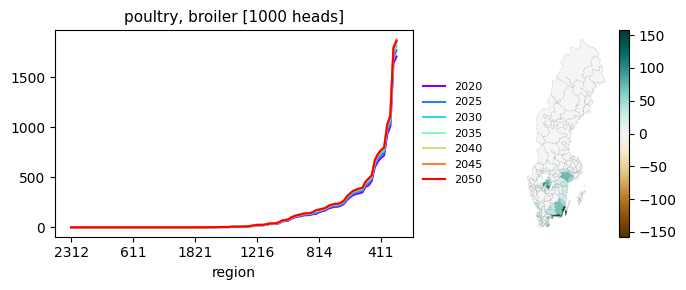

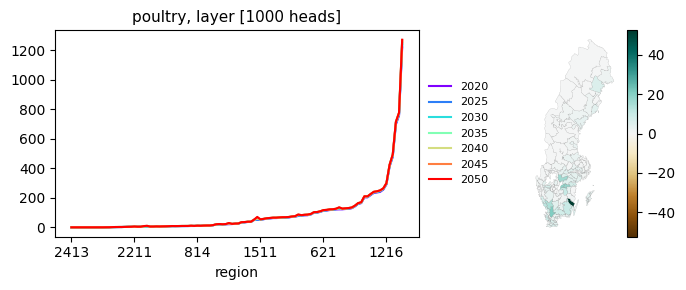

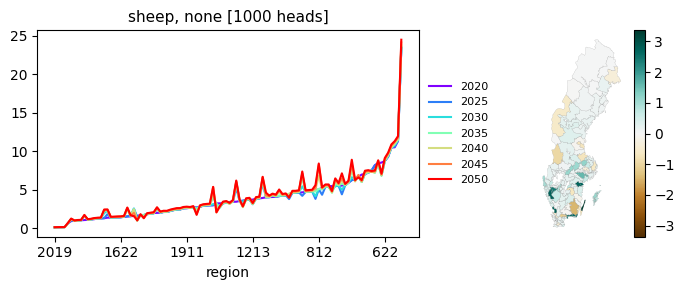

FAI_no_cows
-----------


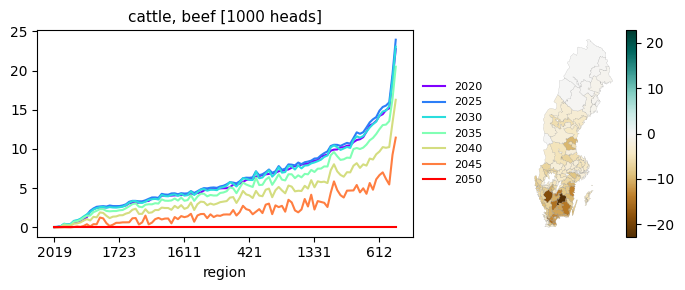

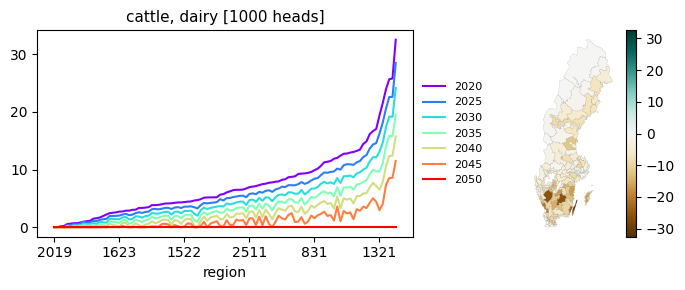

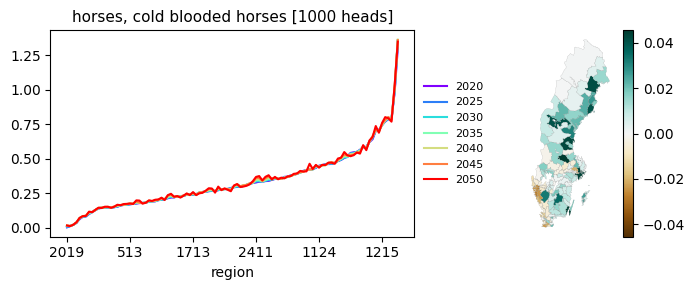

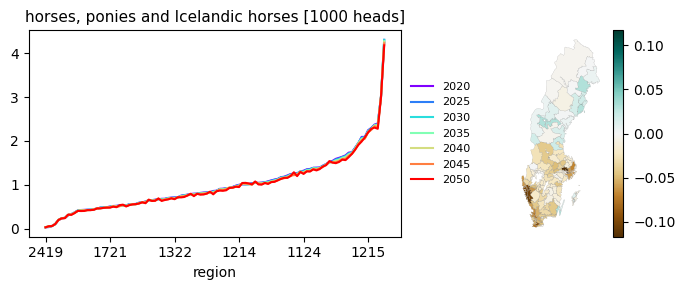

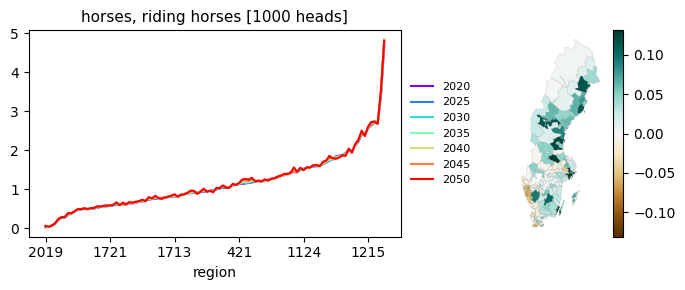

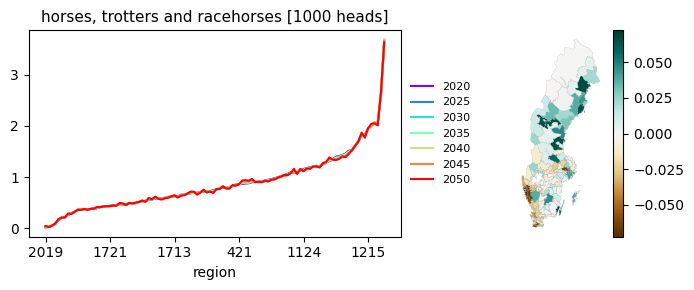

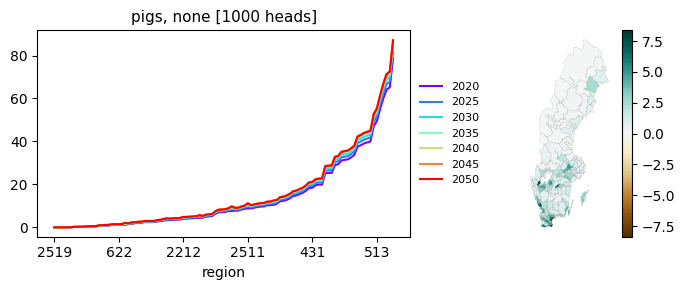

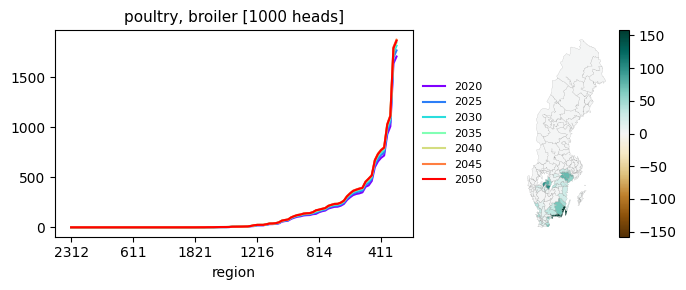

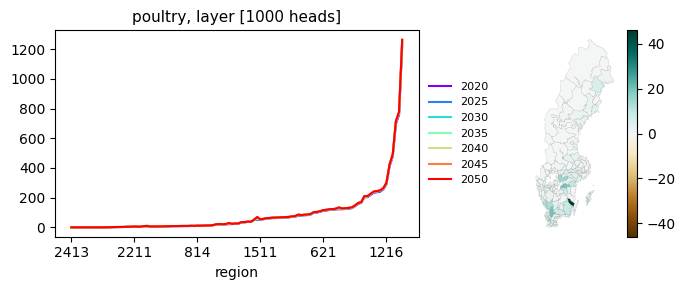

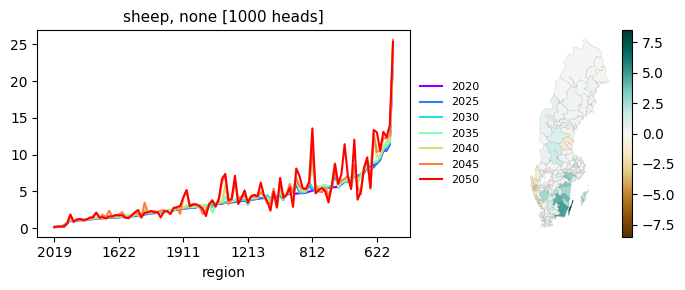

In [15]:
for scn in session.scenarios():
    print(scn)
    print('-'*len(scn))
    years = session.scenarios()[scn]
    plot_data_ = session.get_attr('A','heads',['species','breed','region'], scn=scn).droplevel('scn').T/1000

    for sp,br in plot_data_.index.droplevel('region').unique():
        plot_data = plot_data_.loc[sp,br].groupby('region').sum()
        plot_data['dif'] = (plot_data[years[-1]]-plot_data[years[0]])
        plot_data.sort_values(by=years[0], inplace=True)
    
        fig, axs = plt.subplots(1,2, figsize=(7,3), gridspec_kw={'width_ratios': [2, 1]})
        ax=axs[0]
        plot_data.plot(ax=ax, y=years, kind='line', marker='', linestyle='-', cmap='rainbow')
        # ax.set_yscale('log')
        ax.set_title(f'{sp}, {br} [1000 heads]', size=11)
        ax.legend(loc='center left', ncols=1, bbox_to_anchor=(1, 0.5), frameon=False, fontsize=8)
    
        ax=axs[1]
        lim = max(abs(plot_data['dif']))
        plot.map_from_series(
            plot_data['dif'].replace({np.inf:0, -np.inf:0}).fillna(0),
            ax=ax, vmin=-lim, vmax=lim, cmap='BrBG', edgecolor='grey'
        )
        ax.axis('off')
    
        plt.tight_layout()
        plt.show()

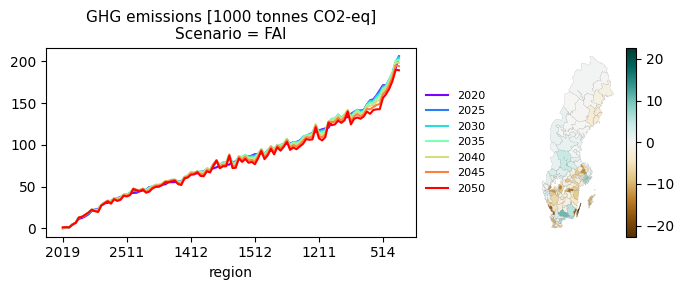

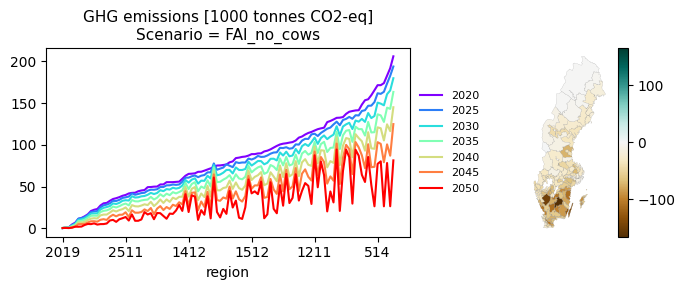

In [16]:
GHG_data = cm.get_GHG(session).T.groupby('region').sum()/1000000

for scn, years in session.scenarios().items():
    
    plot_data = GHG_data.loc[:,scn].copy()
    plot_data['dif'] = (plot_data[years[-1]]-plot_data[years[0]])
    plot_data.sort_values(by=years[0], inplace=True)
    
    fig, axs = plt.subplots(1,2, figsize=(7,3), gridspec_kw={'width_ratios': [2, 1]})
    ax=axs[0]
    plot_data.plot(ax=ax, y=years, kind='line', marker='', linestyle='-', cmap='rainbow')
    # ax.set_yscale('log')
    ax.set_title(f'GHG emissions [1000 tonnes CO2-eq]\nScenario = {scn}', size=11)
    ax.legend(loc='center left', ncols=1, bbox_to_anchor=(1, 0.5), frameon=False, fontsize=8)
    
    ax=axs[1]
    lim = max(abs(plot_data['dif']))
    plot.map_from_series(
        plot_data['dif'].replace({np.inf:0, -np.inf:0}).fillna(0),
        ax=ax, vmin=-lim, vmax=lim, cmap='BrBG', edgecolor='grey'
    )
    ax.axis('off')
    
    plt.tight_layout()
    plt.show()